In [ ]:
import glob as glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt
from sklearn.linear_model import LinearRegression
import proplot as plot 
import cartopy.crs as ccrs
import dask
import statistics as s
import scipy.stats as stats
import matplotlib as mpl
from matplotlib import animation, cm
from matplotlib import colorbar, colors
from netCDF4 import Dataset
from cartopy import config 
from scipy.linalg import lstsq
import cartopy as ct 
from mpl_toolkits.basemap import Basemap
import cartopy.crs as crs
import cartopy.feature as cfeature
from globeplottingfuncs import *

##########################################################################################################################################
#########################################################################################################################################
#### Large SE US Domain ####
lat_r4 = slice(25,43)
lon_r4 = slice(256,291)
loc_r4 = 'SE-US Large Domain'

##########################################################################################################################################
##########################################################################################################################################
#########################################################
variable1 = 'mcape'
var1 = 'CAPE'
name1 = 'cape.'    ### Dimensions: (realization, time, lat, lon)
cesm_title1 = 'S06'
units1 = 'J/kg'

variable2 = 'S06'
var2 = 'S06'
name2 = 's06'    ### Dimensions: (realization, time, lat, lon)
cesm_title2 = 'S06'
units2 = 'm/s'

variable3 = 'capes06'
var3 = 'CAPES06'
name3 = 'capes06'    ### Dimensions: (realization, time, lat, lon)
cesm_title3 = 'CAPES06'
units3 = 'm$^{3}$/s$^{3}$'

variable4 = 'mcin'
var4 = 'CIN'
name4 = 'cin'    ### Dimensions: (realization, time, lat, lon)
cesm_title4 = 'CIN'
units4 = 'J/kg'



ModuleNotFoundError: No module named 'mpl_toolkits.basemap'

# Time Series

In [2]:
mask = xr.open_dataset('p_cal_cesm2_mask.nc')

### Prepare the variables (Upload data, mask, seasonal and area average):

In [ ]:
#################################################### VARIABLE 1 ########################################################
h_files1 = sorted(glob.glob(name1 + '*1870-2014.nc'))
f_files1 = sorted(glob.glob(name1 + '*2015-2100.nc'))
hist1 = xr.open_mfdataset(h_files1, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut1 = xr.open_mfdataset(f_files1, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total1 = xr.concat([hist1,fut1], dim = 'time')[variable1]
mamj1 = total1.groupby('time.year').mean('time')
r4_1 = mamj1.sel(lat = lat_r4, lon = lon_r4).mean(dim=('lat','lon'))

#################################################### VARIABLE 2 ########################################################
h_files2 = sorted(glob.glob(name2 + '*1870-2014.nc'))
f_files2 = sorted(glob.glob(name2 + '*2015-2100.nc'))
hist2 = xr.open_mfdataset(h_files2, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut2 = xr.open_mfdataset(f_files2, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total2 = xr.concat([hist2,fut2], dim = 'time')[variable2]
mamj2 = total2.groupby('time.year').mean('time')
r4_2 = mamj2.sel(lat = lat_r4, lon = lon_r4).mean(dim=('lat','lon'))

#################################################### VARIABLE 3 ########################################################
h_files3 = sorted(glob.glob(name3 + '*1870-2014.nc'))
f_files3 = sorted(glob.glob(name3 + '*2015-2100.nc'))
hist3 = xr.open_mfdataset(h_files3, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut3 = xr.open_mfdataset(f_files3, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total3 = xr.concat([hist3,fut3], dim = 'time')[variable3]
mamj3 = total3.groupby('time.year').mean('time')
r4_3 = mamj3.sel(lat = lat_r4, lon = lon_r4).mean(dim=('lat','lon'))

#################################################### VARIABLE 4 ########################################################
h_files4 = sorted(glob.glob(name4 + '*1870-2014.nc'))
f_files4 = sorted(glob.glob(name4 + '*2015-2100.nc'))
hist4 = xr.open_mfdataset(h_files4, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut4 = xr.open_mfdataset(f_files4, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total4 = xr.concat([hist4,fut4], dim = 'time')[variable4]
mamj4 = total4.groupby('time.year').mean('time')
r4_4 = mamj4.sel(lat = lat_r4, lon = lon_r4).mean(dim=('lat','lon'))*(-1)



### Calculate the ensemble mean for the time series for each variable: 

In [ ]:
#### Region 4 ens ave:
r41_ensave = r4_1.mean(dim = 'realization')
r42_ensave = r4_2.mean(dim = 'realization')
r43_ensave = r4_3.mean(dim = 'realization')
r44_ensave = r4_4.mean(dim = 'realization')


### Calculate the linear trends for each variable and region: 
### Change the index below to get various trends. rX = region number, _X = variable number
### Example: r4_3 = region 4, variable 3....CAPES06 SE US Large Domain

In [ ]:
point = '(2021 - 2050)'
startpoint = '2021'
endpoint = '2050'
dataperiod = '20212050'

### Change to convective index and region of interest from above
index = r4_3            ### Change to convective index and region of interest from above


In [7]:
#######################################################################################################################
################################################ Ensemble Mean Trend: ##################################################
#### Ensemble mean for full time series:
r4_eAve = index.mean(dim = 'realization')                 
x_r4 = r4_eAve.year.values
y_r4 = r4_eAve.values
a_r4 = x_r4.reshape(-1,1)
b_r4 = y_r4.reshape(-1,1)
reg_r4 = LinearRegression().fit(a_r4,b_r4)
trendline_r4 = reg_r4.predict(a_r4)
m_r4 = reg_r4.coef_[0]                   #### where m is slope

#### Ensemble mean for smaller period: 
r4p = index.sel(year = slice(startpoint, endpoint))            
r4_eAvep = r4p.mean(dim = 'realization')
x_r4p = r4_eAvep.year.values
y_r4p = r4_eAvep.values
a_r4p = x_r4p.reshape(-1,1)
b_r4p = y_r4p.reshape(-1,1)
reg_r4p = LinearRegression().fit(a_r4p,b_r4p)
trendline_r4p = reg_r4p.predict(a_r4p)
m_r4p = reg_r4p.coef_[0]          #### where m is slope...USE THIS SLOPE FOR THE ENS AVERAGE!!!!

####################### This loop works!!! ###########################################################
ry = list()
rx = list()
a_r = list()
b_r = list()
reg = list()
trend_r4 = list()
slope_r4= list()

r4_LT = index.sel(year=slice(startpoint, endpoint))        

for i in range(len(r4_3)):
    ry.append(r4_LT[i,:].values)
    rx.append(r4_LT[i,:].year.values)
    a_r.append(rx[i].reshape(-1,1))
    b_r.append(ry[i].reshape(-1,1))
    reg.append(LinearRegression().fit(a_r[i], b_r[i]))
    trend_r4.append(reg[i].predict(a_r[i]))
    slope_r4.append(reg[i].coef_[0])

############################################### Find the max and min: #######################################################
max_index_r4 = slope_r4.index(np.max(slope_r4))    
min_index_r4 = slope_r4.index(np.min(slope_r4))     

r4_maxTrend = trend_r4[max_index_r4]
r4_minTrend = trend_r4[min_index_r4]
r4_maxEns = index[max_index_r4]                    
r4_minEns = index[min_index_r4]                        

ioi_indexMin = min_index_r4
ioi_indexMax = max_index_r4

print('Max index: ' + str(max_index_r4) + ' slope = ' + str(round(np.max(slope_r4),3)))
print('Min index: ' + str(min_index_r4) + ' slope = ' + str(round(np.min(slope_r4),3)))
print('The ensemble average for '+ point + ' is: ' + str(round(float(m_r4p),3)))



/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encoun

/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


Max index: 23 slope = 77.641
Min index: 25 slope = -17.542
The ensemble average for (2021 - 2050) is: 24.145


/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


# Trend Map Analysis

###### Done one variable and ensemble at a time!!!! 

In [ ]:
variable = 'capes06'                   ##### or variableX
var = 'capes06'
name = 'capes06'   
plot_title = 'MAMJ CAPES06'

# define a function to compute a linear trend of a timeseries
def linear_trend(x):
    pf = np.polyfit(x.year, x, 1)
    # need to return an xr.DataArray for groupby
    return xr.DataArray(pf[0])


NameError: name 'units3' is not defined

In [5]:
ensMean_data = xr.open_dataset(var + '.ens.trend.unstacked.mamj.'+dateperiod+'.nc').__xarray_dataarray_variable__
# ensMean_data = xr.open_dataset('cin.trends.singleEns.unstacked.mamj.20202049.nc').__xarray_dataarray_variable__

Ensembled = ensMean_data*10         #### Multiply by 10 to get per decade!


In [8]:
############################## Open files, get seasonal average, and period of interest: #######################################
##### Dont worry about over riding data from above...they are labeled with a parameter corresponding number!
h_files = sorted(glob.glob(var + '*1870-2014.nc'))
f_files = sorted(glob.glob(var + '*2015-2100.nc'))
hist = xr.open_mfdataset(h_files, concat_dim = 'realization', combine = 'nested').sel(lat = lat_CONUS, lon = lon_CONUS)#*(-1)
fut = xr.open_mfdataset(f_files, concat_dim = 'realization', combine = 'nested').sel(lat = lat_CONUS, lon = lon_CONUS)#*(-1)
total = xr.concat([hist,fut], dim = 'time')#[name]
mamj = total.groupby('time.year').mean('time')
period_fut = mamj.sel(year = slice('2021', ))


NameError: name 'startpoint' is not defined

In [ ]:
####### Calculate the linear trend for the smallest trend:      ## NOTICE THIS IS FROM THE FUTURE DATASET!
trendIndex = period_fut[variable3][:,ioi_indexMin,:,:]
index_stack = trendIndex.stack(allpoints = ['lat','lon'])
LT_calc_min = index_stack.groupby('allpoints').apply(linear_trend)
LT_min = LT_calc_min.unstack('allpoints')
LT_mind = LT_min*10        

In [ ]:
####### Calculate the linear trend for the largest trend:       ## NOTICE THIS IS FROM THE FUTURE DATASET!
trendIndex = period_fut[var][:,ioi_indexMax,:,:]
index_stack = trendIndex.stack(allpoints = ['lat','lon'])
LT_calc_max = index_stack.groupby('allpoints').apply(linear_trend)
LT_max = LT_calc_max.unstack('allpoints')
LT_maxd = LT_max*10         

### Calculate the natural variability (SingleMember - EnsembleMean = NaturalVariability)

In [13]:
internal_min = LT_mind - Ensembled
internal_max = LT_maxd - Ensembled

/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: ProPlotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  app.launch_new_instance()
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:17: ProPlotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/xarray/plot/plot.py:1426: ProPlotWarning: Ignoring levels=[-2500, -2400, -2300, -2200, -2100, -2000, -1900, -1800, -1700, -1600, -1500, -1400, -1300, -1200, -1100, -1000, -900, -800, -700, -600, -500, -400, -300, -200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500]. Instead using 

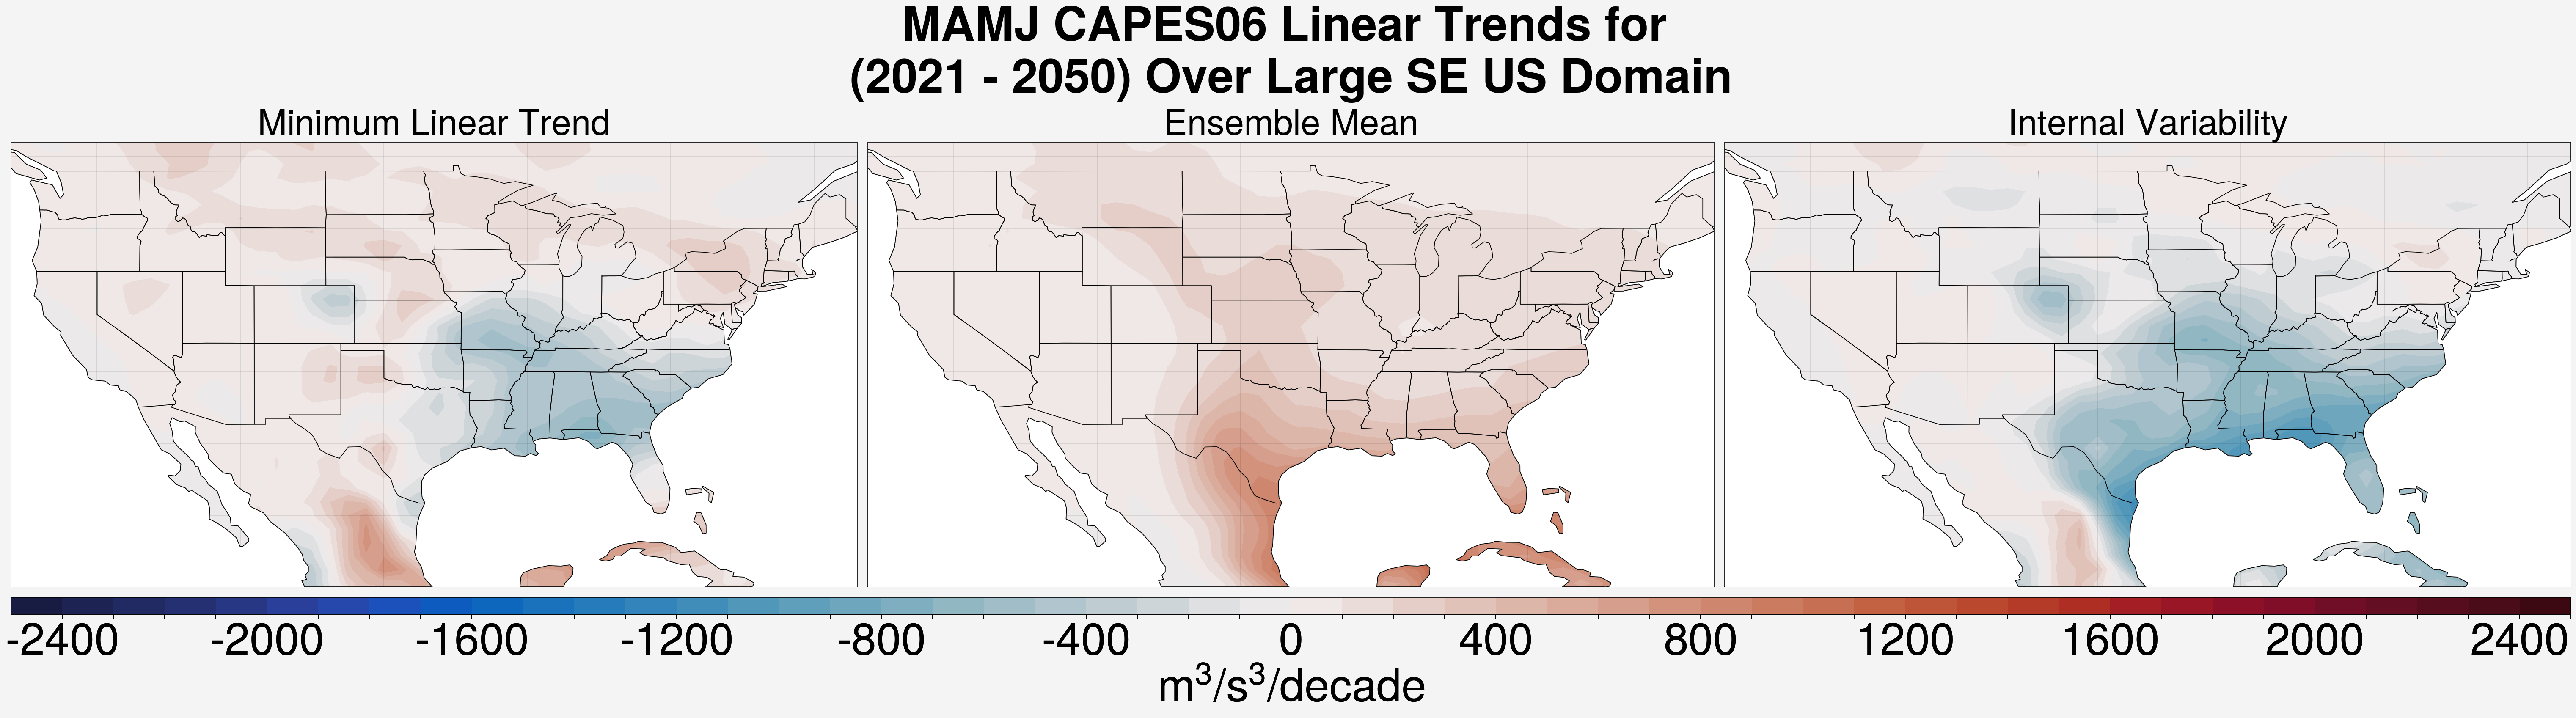

In [ ]:
trend_type = 'Minimum'
plt_ens = LT_mind
plt_diff = internal_min

####################################################################
levels = list(np.arange(-2500,2600,100))
cmap = 'cmo.balance'
fig, axs = pplt.subplots(ncols=3, nrows=1, axwidth=10, proj='pcarree')
ax1,ax2,ax3 = axs
axs.format(coast = True, latlim = (20,51), lonlim = (234,293),  innerborders = True)  ##latlim = (15,52), lonlim = (230,295) -- larger lat range
fig.suptitle(plot_title +' Linear Trends for \n' + point + ' Over Large SE US Domain', fontsize = 40)
axs.add_feature(ct.feature.OCEAN, zorder=100, edgecolor='k', color = 'white')
axs.coastlines(edgecolor = 'k')
a = plt_ens.plot.contourf(ax=ax1, levels =levels, add_colorbar = False, cmap = cmap, extend = 'neither')
Ensembled.plot.contourf(ax=ax2, levels =levels, add_colorbar = False, cmap = cmap, extend = 'neither')
plt_diff.plot.contourf(ax=ax3, levels =levels, add_colorbar = False, cmap = cmap, extend = 'neither')

ax1.set_title(trend_type + ' Linear Trend', fontsize = 30)
ax2.set_title('Ensemble Mean', fontsize = 30)
ax3.set_title('Internal Variability', fontsize = 30)
axs.add_feature(ct.feature.COASTLINE, zorder=100)
cbar = fig.colorbar(a,  loc="bottom", cmap = cmap, labelsize= 38, label = units + '/decade', shrink = 1)
ticks = range(-2400, 2401, 400)
labels = [str(t) if t % 400 == 0 else '' for t in range(-2400, 2401, 100)]
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize = 38)


# plt.savefig('Figures/InternalTrends/'+ name + '_'+ dataperiod + '_'+ trend_type + '_internalvar_3panel.jpg')


/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: ProPlotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  app.launch_new_instance()
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:17: ProPlotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/xarray/plot/plot.py:1426: ProPlotWarning: Ignoring levels=[-2500, -2400, -2300, -2200, -2100, -2000, -1900, -1800, -1700, -1600, -1500, -1400, -1300, -1200, -1100, -1000, -900, -800, -700, -600, -500, -400, -300, -200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500]. Instead using 

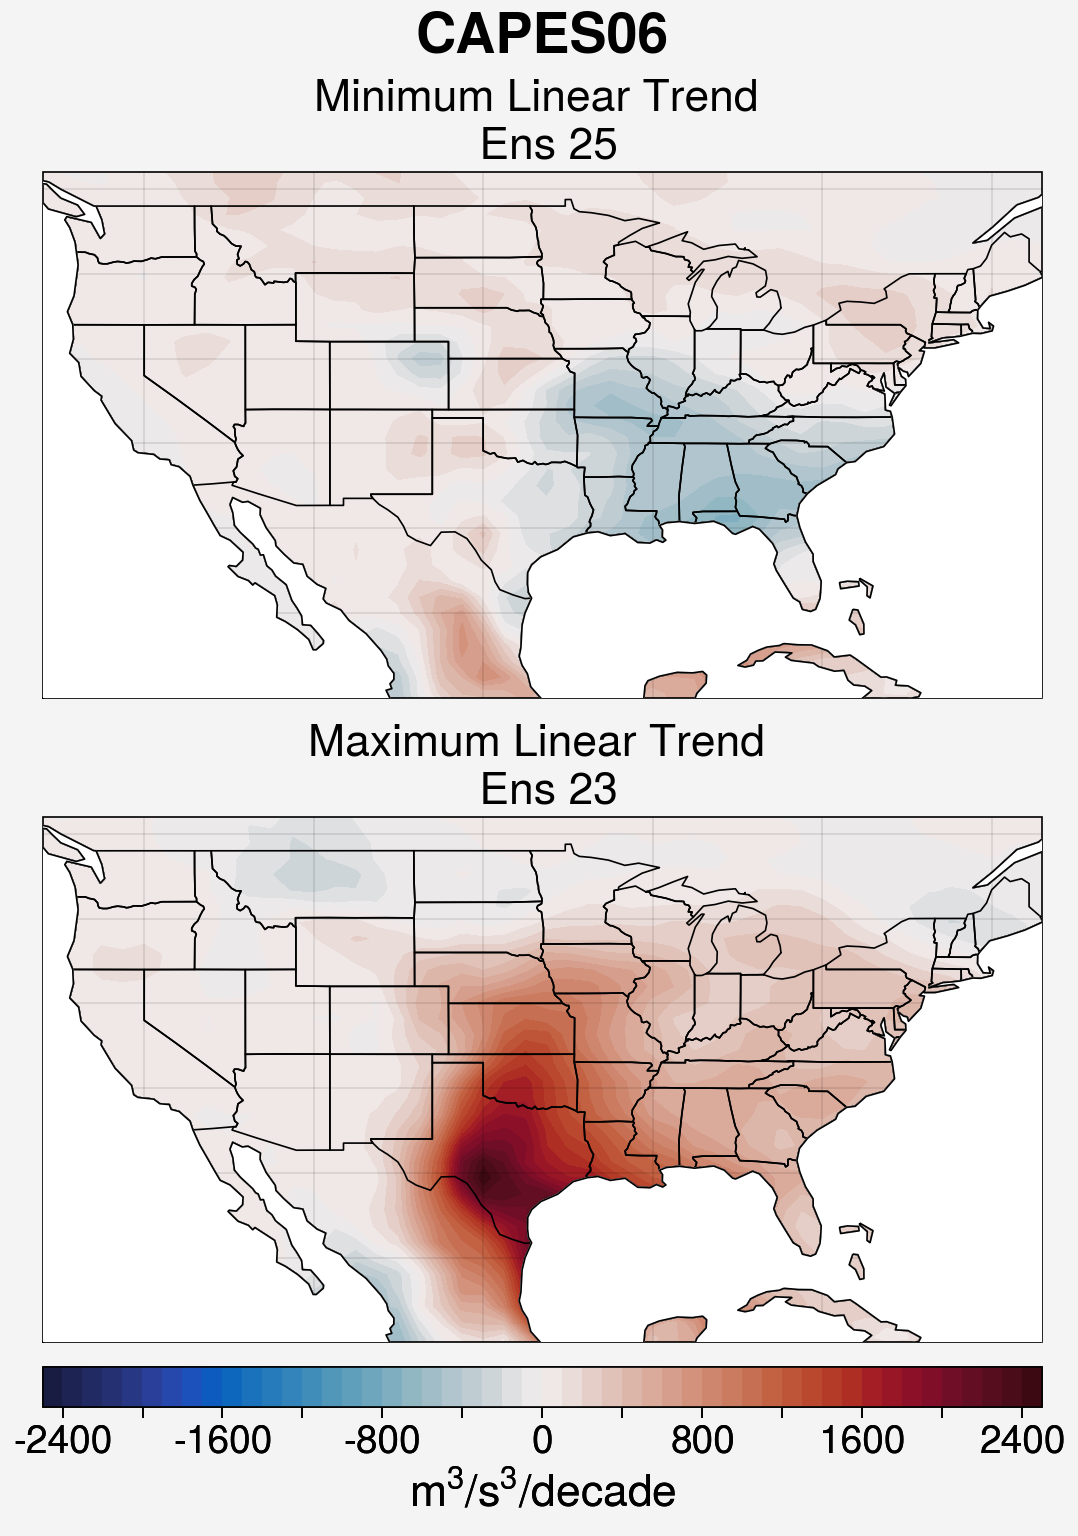

In [ ]:
# trend_type = 'Minimum'
plt_min = LT_mind
plt_max = LT_maxd

####################################################################
# plt.rcParams['figure.facecolor'] = 'white'
levels = list(np.arange(-2500,2600,100))
cmap = 'cmo.balance'
fig, axs = pplt.subplots(ncols=1, nrows=2, axwidth=5, proj='pcarree')
ax1,ax2 = axs
axs.format(coast = True, latlim = (20,51), lonlim = (234,293),  innerborders = True)  ##latlim = (15,52), lonlim = (230,295) -- larger lat range
# fig.set_figheight(2)
# fig.set_figwidth(12)
fig.suptitle('CAPES06', fontsize = 20)
# axs.add_feature(ct.feature.COASTLINE)
axs.add_feature(ct.feature.OCEAN, zorder=100, edgecolor='k', color = 'white')
axs.coastlines(edgecolor = 'k')
a = plt_min.plot.contourf(ax=ax1, levels =levels, add_colorbar = False, cmap = cmap, extend = 'neither')
plt_max.plot.contourf(ax=ax2, levels =levels, add_colorbar = False, cmap = cmap, extend = 'neither')

ax1.set_title('Minimum Linear Trend \n Ens ' + str(ioi_indexMin), fontsize = 16)#, fontweight = 'bold')
ax2.set_title('Maximum Linear Trend \n Ens ' + str(ioi_indexMax), fontsize = 16)#, fontweight = 'bold')
axs.add_feature(ct.feature.COASTLINE, zorder=100)#, edgecolor='k')

cbar = fig.colorbar(a,  loc="bottom", cmap = cmap, labelsize= 16, label = units + '/decade', shrink = 1)
ticks = range(-2400, 2401, 400)
labels = [str(t) if t % 400 == 0 else '' for t in range(-2400, 2401, 100)]
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize = 14)


# plt.savefig('Figures/InternalTrends/'+ name + '_'+ dataperiod + '_internalvar_2panelEXTREME.jpg')
